# Logistic Regression Model for Dementia Prediction in Zimbabwe

## Project Overview
This notebook implements a predictive pipeline to estimate the probability of dementia among adults aged $\ge 60$ in Zimbabwe. Following the study plan in `plan.md`, this implementation covers the full lifecycle: **Data Cleaning $\rightarrow$ EDA $\rightarrow$ Preprocessing $\rightarrow$ Logistic Regression Modelling $\rightarrow$ Evaluation**.

### Key Objectives:
1. **Clean** a noisy synthetic dataset containing sentinel codes and logical errors.
2. **Explore** the associations between sociodemographic, vascular, and lifestyle factors and dementia.
3. **Build** an interpretable Logistic Regression model to identify key risk factors.
4. **Validate** model performance using AUC-ROC and calibration curves.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report, 
                             confusion_matrix, brier_score_loss, precision_recall_curve)
import statsmodels.api as sm
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Data Ingestion

In [2]:
df = pd.read_csv('data.csv')
print(f"Initial dataset shape: {df.shape}")
df.head()

Initial dataset shape: (12168, 31)


,participant_id,interview_date,province,residence,sex,age_years,marital_status,education_years,employment_status,monthly_household_income_usd,...,bmi_kg_m2,gds15_score,hearing_difficulty,vision_difficulty,smoking_status,alcohol_use,physical_activity_level,fruit_veg_servings_per_day,cognitive_screen_score,dementia_status
0,ZW-00001,12/11/2024,Mashonaland West,Urban,F,62,Married,6.0,Unemployed,20.0,...,16.8,2.0,0.0,0.0,Never,NaN,High,2.0,25.0,0
1,ZW-00002,2024-05-12,Manicaland,Urban,F,61,Widowed,7.0,Retired,65.0,...,22.6,2.0,0.0,0.0,Never,NaN,Low,6.0,24.0,0
2,ZW-00003,23/02/2024,Harare,Urban,M,68,Widowed,NaN,Unemployed,45.0,...,21.1,4.0,0.0,0.0,Never,NaN,Low,4.0,25.0,0
3,ZW-00004,2024-09-23,Masvingo,Rural,F,61,Widowed,3.0,Retired,15.0,...,16.5,3.0,0.0,0.0,Never,NaN,High,5.0,29.0,0
4,ZW-00005,19/04/2024,Mashonaland West,Urban,M,66,Married,8.0,Retired,NaN,...,14.4,3.0,0.0,0.0,Former,NaN,High,5.0,27.0,0


## 2. Data Cleaning
The dataset contains engineered defects. We apply a rigorous cleaning protocol to ensure data quality.

In [3]:
# 2.1 Handle Sentinel Codes
# Converting survey sentinels (-99: Refusal, 88: Don't know, 99: N/A) to NaN
sentinels = [-99, 88, 99]
df.replace(sentinels, np.nan, inplace=True)

# 2.2 Deduplication
initial_count = len(df)
df = df.drop_duplicates(subset=['participant_id'])
print(f"Removed {initial_count - len(df)} duplicate records.")

# 2.3 Range and Sanity Checks
# Age must be 60-110
df = df[(df['age_years'] >= 60) & (df['age_years'] <= 110)]

# Education cannot exceed 25 years
df.loc[df['education_years'] > 25, 'education_years'] = np.nan

# GDS15 score must be 0-15
df.loc[(df['gds15_score'] < 0) | (df['gds15_score'] > 15), 'gds15_score'] = np.nan

# 2.4 Categorical Harmonization
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.title()
    df[col] = df[col].replace('Nan', np.nan)

# Specific synonym mapping
mapping = {'Ex-Smoker': 'Former', 'Neg': 'Negative', 'Pos': 'Positive'}
df.replace(mapping, inplace=True)

# 2.5 Logical Contradiction Resolution
# If hypertension_dx is 'No' but takes_bp_medication is '1', we mark the DX as NaN (uncertain)
mask = (df['hypertension_dx'] == 0) & (df['takes_bp_medication'] == 1)
df.loc[mask, 'hypertension_dx'] = np.nan

# Correct BP transpositions (Diastolic cannot be >= Systolic)
bp_mask = df['diastolic_bp_mmhg'] >= df['systolic_bp_mmhg']
df.loc[bp_mask, ['systolic_bp_mmhg', 'diastolic_bp_mmhg']] = np.nan

print(f"Cleaned dataset shape: {df.shape}")

Removed 168 duplicate records.
Cleaned dataset shape: (11851, 31)


## 3. Exploratory Data Analysis (EDA)
Visualizing missingness and the relationship between risk factors and dementia.

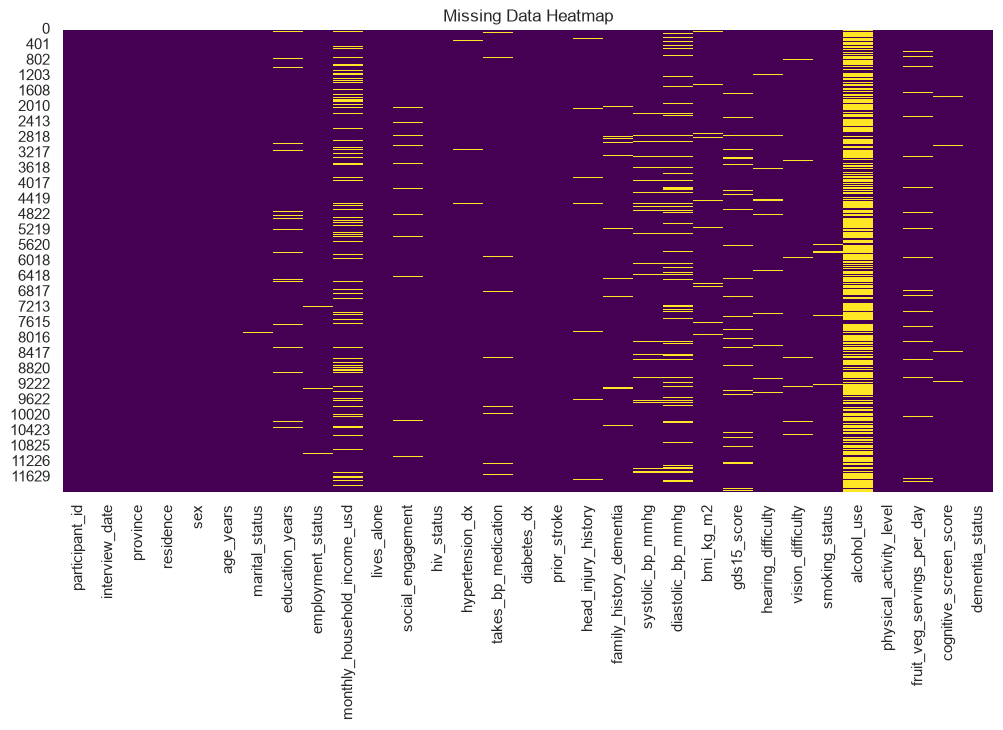

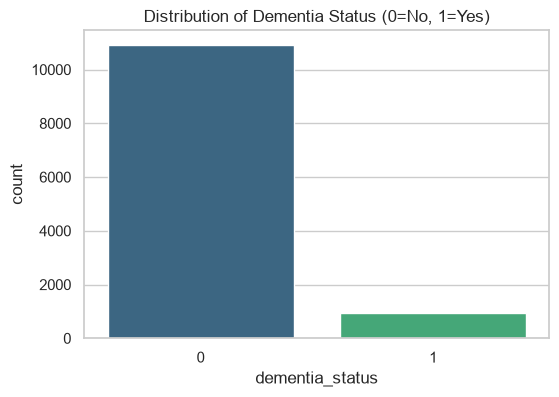

In [4]:
# 3.1 Missingness Map
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.show()

# 3.2 Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='dementia_status', palette='viridis')
plt.title("Distribution of Dementia Status (0=No, 1=Yes)")
plt.show()

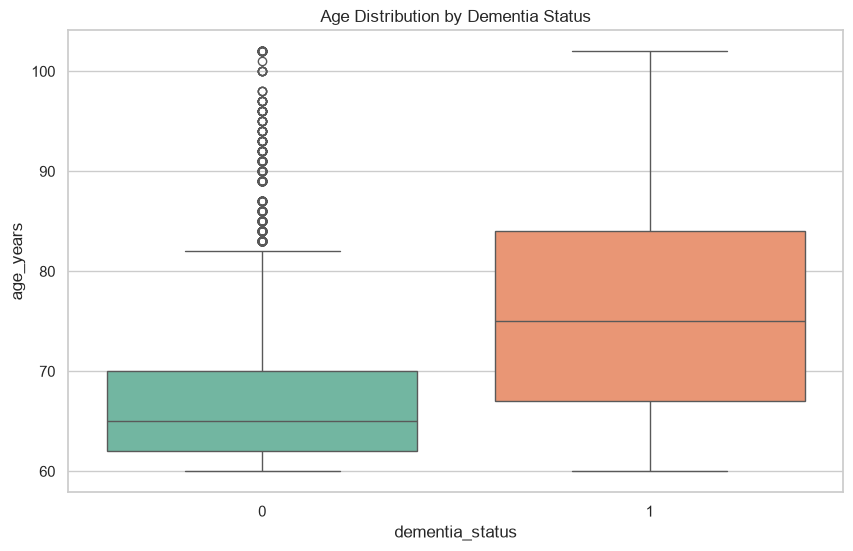

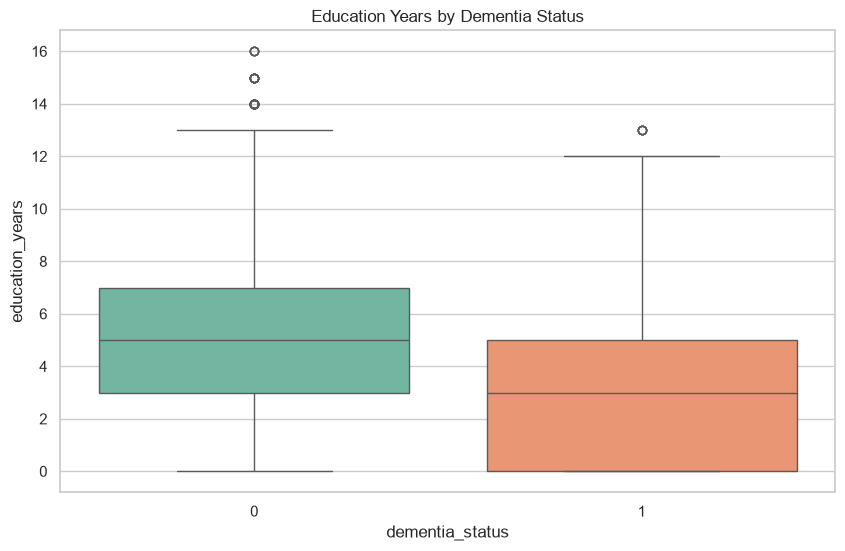

In [5]:
# 3.3 Feature Analysis: Age vs Dementia
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='dementia_status', y='age_years', palette='Set2')
plt.title("Age Distribution by Dementia Status")
plt.show()

# 3.4 Feature Analysis: Education vs Dementia
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='dementia_status', y='education_years', palette='Set2')
plt.title("Education Years by Dementia Status")
plt.show()

## 4. Preprocessing
Preparing the data for Logistic Regression. We split the data *before* imputation to prevent data leakage.

In [6]:
# Define predictors and target
# Quarantining 'cognitive_screen_score' to prevent leakage
drop_cols = ['participant_id', 'interview_date', 'cognitive_screen_score']
X = df.drop(columns=drop_cols + ['dementia_status'])
y = df['dementia_status']

# 4.1 Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 4.2 Imputation
num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train_num = num_imputer.fit_transform(X_train[num_cols])
X_test_num = num_imputer.transform(X_test[num_cols])

X_train_cat = cat_imputer.fit_transform(X_train[cat_cols])
X_test_cat = cat_imputer.transform(X_test[cat_cols])

# 4.3 Encoding
ohe = OneHotEncoder(drop='first', sparse_output=False)
X_train_cat_enc = ohe.fit_transform(X_train_cat)
X_test_cat_enc = ohe.transform(X_test_cat)

# 4.4 Scaling
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

# Combine processed features
X_train_final = np.hstack([X_train_num_scaled, X_train_cat_enc])
X_test_final = np.hstack([X_test_num_scaled, X_test_cat_enc])

feature_names = list(num_cols) + list(ohe.get_feature_names_out(cat_cols))
print(f"Final feature set size: {X_train_final.shape[1]}")

Final feature set size: 87


## 5. Modelling
Using Logistic Regression to predict dementia and analyze odds ratios.

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.75      0.85      2184
           1       0.19      0.70      0.30       187

    accuracy                           0.75      2371
   macro avg       0.58      0.73      0.57      2371
weighted avg       0.91      0.75      0.80      2371

AUC-ROC Score: 0.7940
Brier Score: 0.1803


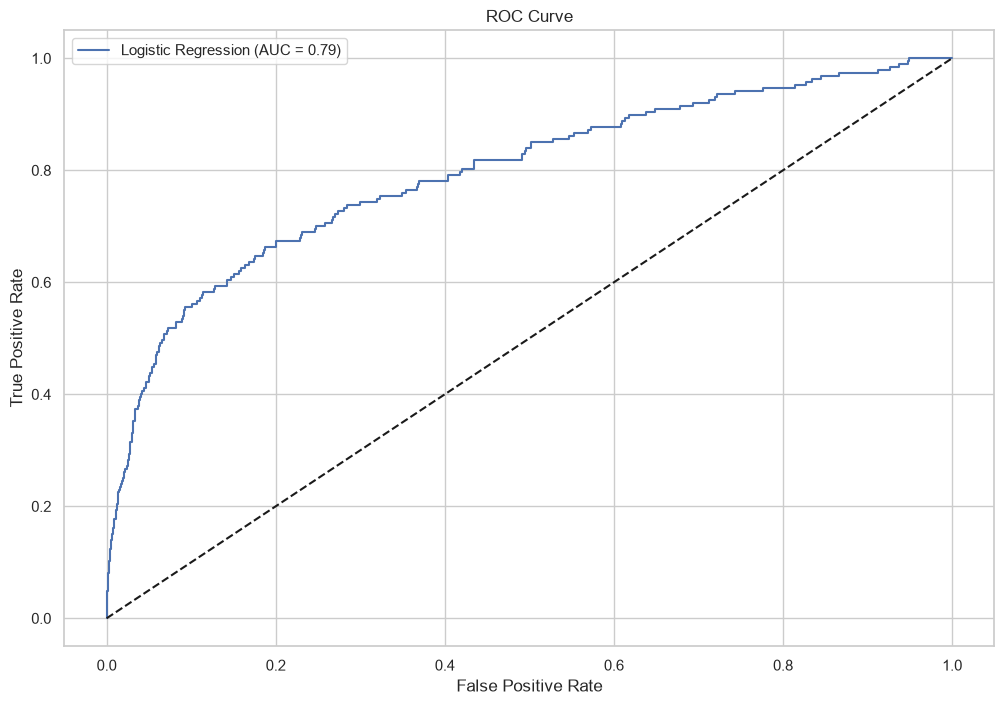

In [7]:
# 5.1 Model Training
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train_final, y_train)

# 5.2 Predictions
y_pred = model.predict(X_test_final)
y_prob = model.predict_proba(X_test_final)[:, 1]

# 5.3 Evaluation Metrics
print("Classification Report:\n", classification_report(y_test, y_pred))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Brier Score: {brier_score_loss(y_test, y_prob):.4f}")

# ROC Curve Visualization
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob):.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## 6. Interpretability: Odds Ratios
Using `statsmodels` for a more detailed statistical summary and confidence intervals.

In [8]:
# Re-running with statsmodels for detailed statistics
X_sm = sm.add_constant(X_train_final)
sm_model = sm.Logit(y_train, X_sm).fit()

summary = sm_model.summary2().tables[1]
summary['Odds_Ratio'] = np.exp(summary['Coef.'])
summary['OR_Lower_CI'] = np.exp(summary['[0.025'])
summary['OR_Upper_CI'] = np.exp(summary['[0.975]'])

# Plotting the Forest Plot for Top Predictors
top_predictors = summary.sort_values('P>|z|').head(15)
plt.figure(figsize=(10, 8))
plt.errorbar(top_predictors['Odds_Ratio'], top_predictors.index, 
             xerr=[top_predictors['Odds_Ratio'] - top_predictors['OR_Lower_CI'], 
                   top_predictors['OR_Upper_CI'] - top_predictors['Odds_Ratio']],
             fmt='o', color='black', capsize=5)
plt.axvline(x=1, color='red', linestyle='--')
plt.xscale('log')
plt.title("Odds Ratios for Dementia Predictors (Top 15 by p-value)")
plt.xlabel("Odds Ratio (Log Scale)")
plt.show()

         Current function value: 0.225220
         Iterations: 35


KeyError: '[0.975]'